# Using Multi Sampling To Avoid Edge Clustering

This example shows how to avoid interval-edge clustering by using the multi-sampling feature. It builds upon example 2. 
**Please go through the example 1 and 2 before this one** <br>

## About the Multi-Sampling Feature and the Problem it Solves
The feature allows you to control the number of samples done for each interval per iteration of the orchestration algorithm. <br> **Let us go through an example:** <br>
Imagine you have the intervals [(1, 2), (2, 3)], the occurrences [3, 4] and a deterministic sample space always resulting in "A". Then, by default the orchestration algorithm samples events sequentially adds to the future events queue. Furthermore, we cannot allow the sampled timestamps to have a numerical value less than the prior, as it would break the realistic temporal properties of the generator (we would go back in time). As a result, events often ends up clustering at the end of the intervals if the variation is high. <br> <br>
To solve this, all events of an interval can be sampled simultaneously and sorted for each orchestration iteration, eliminating the need for the greater than prior constraint. This is implemented by parsing a function $f: S \rightarrow \mathbb{Z}^+$ to the `no_multi_samples_generator`, where $S$ is the state-space. *no_multi_samples* stand for number of multi samples and *generator* denotes that it is a function. <br>
The timestamp generator defaults to not doing multi-sampling, implemented as doing as many multi-samples as there are occurrences: `lambda state: state["occurrences"][state["current_interval"]]`. To sample all timestamps of an interval at once the function should return 1, meaning it will do one multi-sample with all the samples: `no_multi_samples_generator=lambda state: 1`

## Imports

In [9]:
import numpy as np
import logging

from EventStreamGenerator import EventTimestampGenerator, EventSampleSpace, EventStreamGenerator
from analytics import plot_timeline_with_colors, count_number_of_occurrences_in_intervals

## Configure Logging

Logging is configured to show INFO level messages and above, with a specific format that includes the timestamp, logger name, log level, and message.

In [10]:
logger = logging.getLogger(__name__)

logging.basicConfig(
    level=logging.INFO,                            
    format="%(asctime)s %(name)s %(levelname)s: %(message)s",
)

## Configure Inputs

The inputs are configured for this example. Including:
- **max_time**: End boundary of intervals and maximum time the simulation will run
- **intervals**: 1 second intervals [(0, 1), (1, 2), (2, 3)]
- **occurrences**: The number of times the event are to occur in each interval [4, 8, 12]. 
- **time_scaling**: This scales the time, if set to 1 it is outputting in real-time, and when set to 100 it runs 100 times faster than real-time.
- **event_handler**: This function is invoked with event details whenever an event is occurring.  
- **noise_sds**: Noise standard deviations - the standard deviations of the noises to be added to the samples, which is normally distributed with mean 0.
- **occurrence_noise_sds**: Occurrences Noise Standard Deviations - the standard deviations of the noises to be added to the "number of occurrences" samples, which is normally distributed with mean occurrences[i], for each interval i.

In [11]:
max_time = 3
intervals = [(i, i+1) for i in range(max_time)]
occurrences = [4*(i+1) for i in range(max_time)]
time_scaling = 1 # 1 is real-time

print("Time intervals:", intervals)
print("Occurrences:", occurrences)

# Callback function to handle events
def event_handler(event):
    logger.info(f"New event: {event}")
    logger.info("--------")


# NEW INPUTS
# Event Noise Standard Deviation
__noise_sd = .5
noise_sds = [__noise_sd]*max_time

# Occurrence Noise Standard Deviation
__occurrence_noise_sd = 1
occurrence_noise_sds = [__occurrence_noise_sd]*max_time

print("Noise Standard Deviations:", noise_sds)
print("Occurrence Noise Standard Deviations:", occurrence_noise_sds)

Time intervals: [(0, 1), (1, 2), (2, 3)]
Occurrences: [4, 8, 12]
Noise Standard Deviations: [0.5, 0.5, 0.5]
Occurrence Noise Standard Deviations: [1, 1, 1]


## Configure Constraints

Constraints can be used on both event timestamp generator (ETG) and event samples spaces (ESS). When a valid non-empty constraint set is added, the ETG and ESS will enforce that these constraints are met by resampling.

**Not that the greater than prior constraint on the timestamps have been removed**

In [12]:
from typing import Any, Callable, Set
# Timestamp Constraints
timestamp_constraints: Set[Callable[[dict, Any], bool]]={
                     # Every timestamp (ts) must be non-negative
                     lambda state, ts: ts > 0, 
                     # Every timestamp (ts) must be within its own interval
                     lambda state, ts: state["time_intervals"][state["current_interval"]][0] <= ts < state["time_intervals"][state["current_interval"]][1]
                }
# Occurrence Constraints
occurrences_constraints: Set[Callable[[dict, Any], bool]]={
    # The number of occurrences must be non-negative
    lambda state, o: o >= 0
}

## Define Event

**Note the parsing of the constant 1 function to the no_multi_samples_generator parameter**

In [13]:
class StochasticETG(EventTimestampGenerator):
    """Class representing the frequency of events over time, defined by occurrences and time intervals"""
    def __init__(self, occurrences, time_intervals, timestamp_constraints, occurrences_constraints, noise_sds, occurrences_sds):
        self.noise_sds = noise_sds
        self.occurrences_sds = occurrences_sds
        super().__init__(occurrences, time_intervals, timestamp_constraints, occurrences_constraints, no_multi_samples_generator=lambda state: 1)
    
    def sample_noise(self, i):
        return np.random.normal(loc=0, scale=self.noise_sds[i])
    
    def sample_occurrences(self, occurrences_i, i):
        return int(np.round(np.random.normal(loc=occurrences_i, scale=self.occurrences_sds[i])))

class RedBlueSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
        self.values = ["red", "blue"]
        self.probabilities = [0.5, 0.5]

    def sample(self, t):
        return str(np.random.choice(self.values, p=self.probabilities))
    

etg = StochasticETG(occurrences, intervals, timestamp_constraints, occurrences_constraints, noise_sds, occurrence_noise_sds)
ess = RedBlueSampleSpace()
event = (etg, ess)

## Run Generator

In [14]:
# Initialize the TimeSeriesGenerator with the ETG and ESS
time_series_generator = EventStreamGenerator([event], event_handler)
# Run the generator to produce data for "max_time" time with a time-scaling of 100
data = time_series_generator.run(max_time, time_scaling)

# Log results
logger.info(f"Generated data: {data}")

2025-08-15 15:27:37,753 __main__ INFO: New event: (0.0608549202893387, 'blue')
2025-08-15 15:27:37,753 __main__ INFO: --------
2025-08-15 15:27:38,147 __main__ INFO: New event: (0.45491273208140515, 'blue')
2025-08-15 15:27:38,147 __main__ INFO: --------
2025-08-15 15:27:38,249 __main__ INFO: New event: (0.5156640667734003, 'red')
2025-08-15 15:27:38,250 __main__ INFO: --------
2025-08-15 15:27:38,442 __main__ INFO: New event: (0.7288851495424222, 'red')
2025-08-15 15:27:38,443 __main__ INFO: --------
2025-08-15 15:27:38,685 __main__ INFO: New event: (0.9931962866594852, 'blue')
2025-08-15 15:27:38,686 __main__ INFO: --------
2025-08-15 15:27:38,787 __main__ INFO: New event: (1.0503093123603304, 'red')
2025-08-15 15:27:38,788 __main__ INFO: --------
2025-08-15 15:27:38,857 __main__ INFO: New event: (1.1654375294818926, 'red')
2025-08-15 15:27:38,858 __main__ INFO: --------
2025-08-15 15:27:38,983 __main__ INFO: New event: (1.2906818605092314, 'blue')
2025-08-15 15:27:38,983 __main__ IN

## Analyse Results

In [15]:
print(f"Occurrences in intervals: {count_number_of_occurrences_in_intervals(intervals, data)}")

Occurrences in intervals: [5, 9, 14]


## Plot Results

From running the plots multiple times, it is evident that the datapoints are altering between red and blue. 

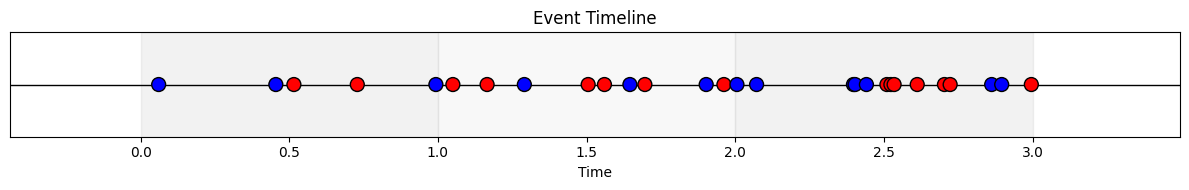

In [16]:
plot_timeline_with_colors(data, intervals)